In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical

# Set Random Seed
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Load Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Preprocessing

#Normalization(0-255 -> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# One-hot Encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
# Model Function
def create_mlp(initializer):
    model = Sequential()

    model.add(Dense(128, activation='relu',kernel_initializer=initializer,input_shape=(784,)))

    model.add(Dense(64, activation='relu',kernel_initializer=initializer))

    model.add(Dense(10, activation='softmax',kernel_initializer=initializer))

    return model

In [ ]:
# Initializers Comparison
initializers = {
    "RandomNormal": tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05),
    "Xavier (GlorotUniform)": tf.keras.initializers.GlorotUniform(),
    "HeNormal": tf.keras.initializers.HeNormal()
}

history_init = {}

print("\n========== WEIGHT INITIALIZATION COMPARISON ==========\n")

for name, init in initializers.items():

    tf.keras.backend.clear_session()

    print(f"Training with {name} Initialization")

    model = create_mlp(init)

    model.compile(
        optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

    history = model.fit(
        X_train, y_train,epochs=10,batch_size=128,validation_data=(X_test, y_test),verbose=1)

    # FINAL TRAINING METRICS
    train_loss = history.history['loss'][-1]
    train_acc = history.history['accuracy'][-1]

    # FINAL TEST METRICS
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"Final Training Accuracy : {train_acc:.4f}")
    print(f"Final Training Loss     : {train_loss:.4f}")
    print(f"Final Test Accuracy     : {test_acc:.4f}")
    print(f"Final Test Loss         : {test_loss:.4f}")
    print("--------------------------------------------------\n")

    history_init[name] = history


========== WEIGHT INITIALIZATION COMPARISON ==========

Training with RandomNormal Initialization


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7930 - loss: 0.7946 - val_accuracy: 0.9380 - val_loss: 0.2042
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9457 - loss: 0.1897 - val_accuracy: 0.9584 - val_loss: 0.1382
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9621 - loss: 0.1318 - val_accuracy: 0.9644 - val_loss: 0.1119
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9714 - loss: 0.0989 - val_accuracy: 0.9691 - val_loss: 0.0963
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9778 - loss: 0.0768 - val_accuracy: 0.9725 - val_loss: 0.0874
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9823 - loss: 0.0616 - val_accuracy: 0.9742 - val_loss: 0.0808
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9858 - loss: 0.0495 - val_accuracy: 0.9741 - val_loss: 0.0791
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9888 - loss: 0.0402 - val_accuracy: 0.

In [ ]:
optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "Adam": Adam(learning_rate=0.001)
}

history_opt = {}

print("\n========== OPTIMIZER COMPARISON (With He Initialization) ==========\n")

for name, opt in optimizers.items():

    tf.keras.backend.clear_session()

    print(f"Training with {name} Optimizer")

    model = create_mlp(tf.keras.initializers.HeNormal())

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=128,
        validation_data=(X_test, y_test),
        verbose=1
    )

    # FINAL TRAINING METRICS
    train_loss = history.history['loss'][-1]
    train_acc = history.history['accuracy'][-1]

    # FINAL TEST METRICS
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"Final Training Accuracy : {train_acc:.4f}")
    print(f"Final Training Loss     : {train_loss:.4f}")
    print(f"Final Test Accuracy     : {test_acc:.4f}")
    print(f"Final Test Loss         : {test_loss:.4f}")
    print("--------------------------------------------------\n")

    history_opt[name] = history


========== OPTIMIZER COMPARISON (With He Initialization) ==========

Training with SGD Optimizer
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5375 - loss: 1.5658 - val_accuracy: 0.8638 - val_loss: 0.5211
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8721 - loss: 0.4885 - val_accuracy: 0.8946 - val_loss: 0.3723
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8955 - loss: 0.3741 - val_accuracy: 0.9103 - val_loss: 0.3194
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9073 - loss: 0.3263 - val_accuracy: 0.9174 - val_loss: 0.2890
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9151 - loss: 0.2966 - val_accuracy: 0.9224 - val_loss: 0.2680
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9214 - loss: 0.2751 - val_accuracy: 0.9275 - val_loss: 0.2520
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9269 - loss: 0.2582 - val_accuracy: 0.9310 - val_loss: 0.2391
Epoch 

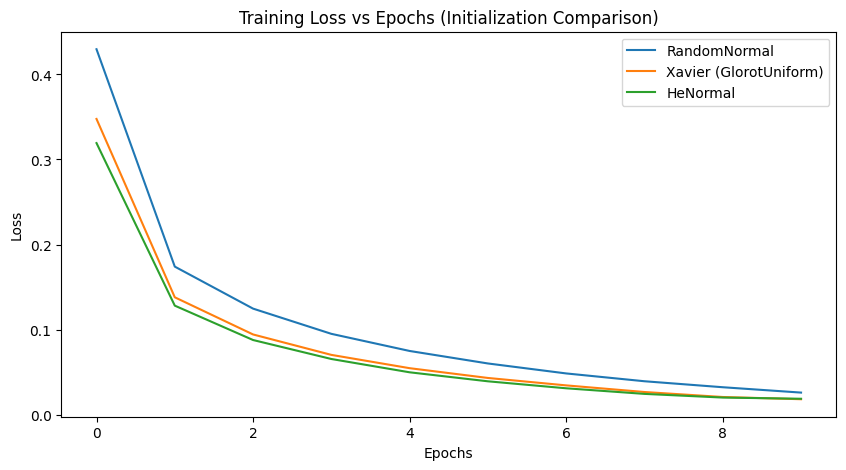

In [ ]:
# Plot - Initializers
plt.figure(figsize=(10,5))
for name, history in history_init.items():
    plt.plot(history.history['loss'], label=name)
plt.title("Training Loss vs Epochs (Initialization Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

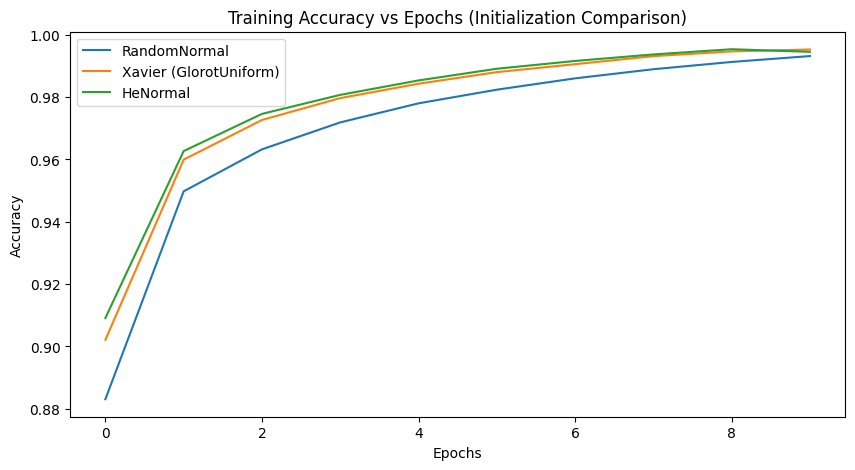

In [ ]:
# Plot - Initializers
plt.figure(figsize=(10,5))
for name, history in history_init.items():
    plt.plot(history.history['accuracy'], label=name)
plt.title("Training Accuracy vs Epochs (Initialization Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

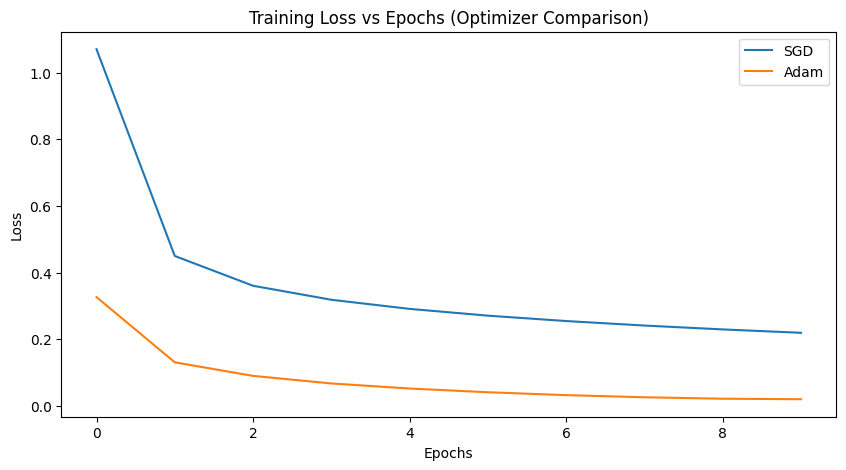

In [ ]:
# Plot - Optimizers
plt.figure(figsize=(10,5))
for name, history in history_opt.items():
    plt.plot(history.history['loss'], label=name)
plt.title("Training Loss vs Epochs (Optimizer Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

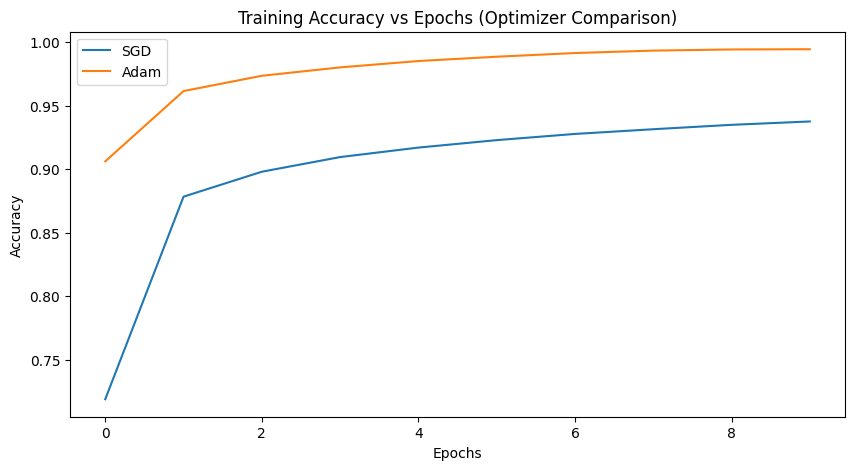

In [ ]:
# Plot - Optimizers
plt.figure(figsize=(10,5))
for name, history in history_opt.items():
    plt.plot(history.history['accuracy'], label=name)
plt.title("Training Accuracy vs Epochs (Optimizer Comparison)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
print("\n===================================")
print("FINAL RESULTS: WEIGHT INITIALIZATION COMPARISON")
print("Optimizer Used : Adam")
print("===================================\n")

print("Initialization               | Train Acc | Test Acc | Train Loss | Test Loss")
print("--------------------------------------------------------------------------")

for name, history in history_init.items():
    train_acc = history.history['accuracy'][-1]
    train_loss = history.history['loss'][-1]

    # Re-evaluate using last trained model
    model = create_mlp(initializers[name])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    model.fit(X_train, y_train, epochs=0, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"{name:28} | {train_acc:.4f}  | {test_acc:.4f} | {train_loss:.4f}    | {test_loss:.4f}")



FINAL RESULTS: WEIGHT INITIALIZATION COMPARISON
Optimizer Used : Adam

Initialization               | Train Acc | Test Acc | Train Loss | Test Loss
--------------------------------------------------------------------------
RandomNormal                 | 0.9932  | 0.1177 | 0.0261    | 2.2986
Xavier (GlorotUniform)       | 0.9953  | 0.0563 | 0.0183    | 2.4030
HeNormal                     | 0.9945  | 0.0894 | 0.0188    | 2.3917


In [ ]:
print("\n===================================")
print("FINAL RESULTS: OPTIMIZER COMPARISON")
print("Initializer Used : He Normal")
print("===================================\n")

print("Optimizer | Train Acc | Test Acc | Train Loss | Test Loss")
print("----------------------------------------------------------")

for name, history in history_opt.items():
    train_acc = history.history['accuracy'][-1]
    train_loss = history.history['loss'][-1]

    model = create_mlp(tf.keras.initializers.HeNormal())
    model.compile(
        optimizer=optimizers[name],
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    model.fit(X_train, y_train, epochs=0, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"{name:8} | {train_acc:.4f}  | {test_acc:.4f} | {train_loss:.4f}    | {test_loss:.4f}")



FINAL RESULTS: OPTIMIZER COMPARISON
Initializer Used : He Normal

Optimizer | Train Acc | Test Acc | Train Loss | Test Loss
----------------------------------------------------------
SGD      | 0.9377  | 0.1385 | 0.2189    | 2.3888
Adam     | 0.9945  | 0.1180 | 0.0194    | 2.3967
